In [341]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Third-party — data science stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_squared_log_error
)
from sklearn.impute import SimpleImputer

# Data Reading

Read the data

In [342]:
df = pd.read_csv("./abalone.csv")

In [343]:
df.head()

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [344]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   object 
 1   length          4177 non-null   float64
 2   diameter        4177 non-null   float64
 3   height          4177 non-null   float64
 4   whole_weight    4177 non-null   float64
 5   shucked_weight  4177 non-null   float64
 6   viscera_weight  4177 non-null   float64
 7   shell_weight    4177 non-null   float64
 8   rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


Check Null Columns

In [345]:
df.isnull().sum()

sex               0
length            0
diameter          0
height            0
whole_weight      0
shucked_weight    0
viscera_weight    0
shell_weight      0
rings             0
dtype: int64

Check if there are duplicates

In [346]:
df.duplicated().sum()

np.int64(0)

To be sure, drop the duplicates

In [347]:
df.drop_duplicates()

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [348]:
df.columns

Index(['sex', 'length', 'diameter', 'height', 'whole_weight', 'shucked_weight',
       'viscera_weight', 'shell_weight', 'rings'],
      dtype='object')

Separate the numerical columns and the categorical columns

In [349]:
numerical_cols = df.select_dtypes(np.number).columns.tolist()
numerical_cols

['length',
 'diameter',
 'height',
 'whole_weight',
 'shucked_weight',
 'viscera_weight',
 'shell_weight',
 'rings']

In [350]:
categorical_cols = ["sex"]
categorical_cols

['sex']

Define the targe columns

In [351]:
target_col = "rings"

Check if the data is sane: There may be data that may be highly error prone. Example: Negative values in height, etc.

In [352]:
df.describe()

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


From the inference above it seems to show that for the length, diameter, length, shucked_weight, shell_weight, and rings (the target) the mean and median are near, this suggest that data is insignificantly skewed. 

Meanwhile for the whole_weight, there is a slight skewness to the right because the mean is larger than the median.

## EDA

Helper Functions

In [353]:
# helper function for interpreting correlation results
def interpret_correlation(corr_value):
    if corr_value > 0.7:
        return "strong positive correlation"
    elif corr_value > 0.3:
        return "moderate positive correlation"
    elif corr_value > 0:
        return "weak positive correlation"
    elif corr_value < -0.7:
        return "strong negative correlation"
    elif corr_value < -0.3:
        return "moderate negative correlation"
    elif corr_value < 0:
        return "weak negative correlation"
    else:
        return "no correlation"

In [354]:
# helper function to interpret level of skewness
def interpret_skewness(skew_value):
    if skew_value > 1:
        return "highly positively skewed"
    elif skew_value > 0.5:
        return "moderately positively skewed"
    elif skew_value > 0:
        return "slightly positively skewed"
    elif skew_value < -1:
        return "highly negatively skewed"
    elif skew_value < -0.5:
        return "moderately negatively skewed"
    elif skew_value < 0:
        return "slightly negatively skewed"
    else:
        return "symmetrical distribution"

Before proceeding, check for the slight skewness on the whole_weight column

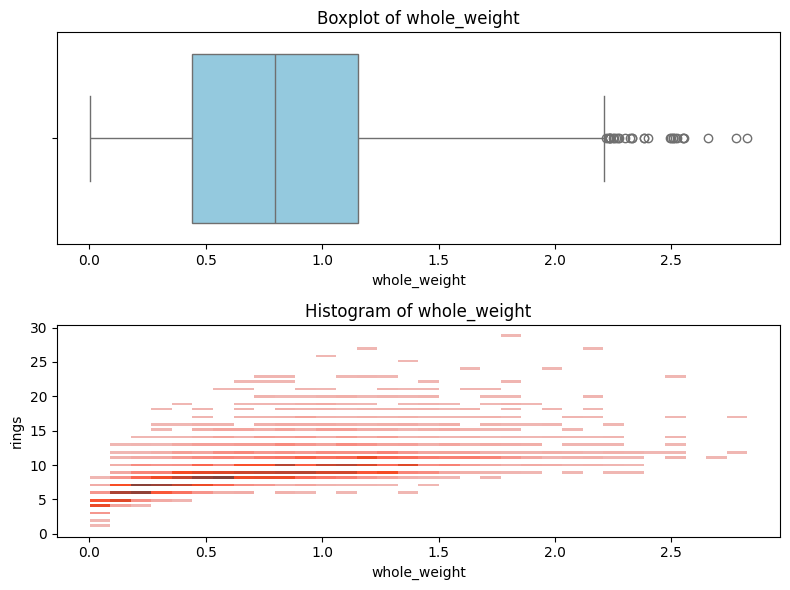

In [355]:
scrutinized_col = "whole_weight"
target_col = "rings"
category_col = "sex"

# Create a figure with 2 rows, 1 column
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))

# Top: Boxplot
sns.boxplot(data=df, x=scrutinized_col, ax=axes[0], color="skyblue")
axes[0].set_title(f"Boxplot of {scrutinized_col}")

# Bottom: Histogram
sns.histplot(data=df, x=scrutinized_col, y=target_col, ax=axes[1], kde=True, color="salmon")
axes[1].set_title(f"Histogram of {scrutinized_col}")

plt.tight_layout()
plt.show()

We can see that the column whole_weight has significant outliers as seen on the positive side of the boxplot from around 2.3 and higher. As we can see in the histogram, there is a linear possible relationship in which the higher the rings, the higher the whole_weight, however, due to the outliers, the data may be skewed.

**Deliberate Decision**: Retain because it could be useful and these outliers may be taken into account in the population later.

Correlation Matrix for the numerical columns

<Axes: >

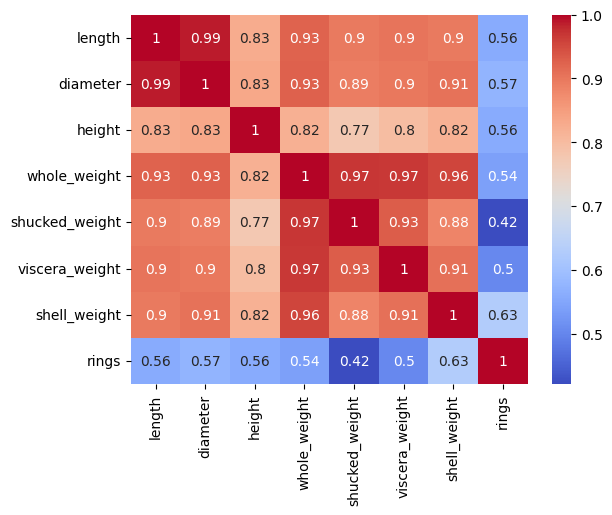

In [356]:
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')

Use the utility functions to see the correlations of each columns to the target column

In [357]:
for col in numerical_cols: 
    print(f"Correlation between '{col}' and '{target_col}': {df[col].corr(df[target_col])} ({interpret_correlation(df[col].corr(df[target_col]))})")

Correlation between 'length' and 'rings': 0.5567195769296182 (moderate positive correlation)
Correlation between 'diameter' and 'rings': 0.5746598513059193 (moderate positive correlation)
Correlation between 'height' and 'rings': 0.5574673244580378 (moderate positive correlation)
Correlation between 'whole_weight' and 'rings': 0.5403896769239006 (moderate positive correlation)
Correlation between 'shucked_weight' and 'rings': 0.42088365794521465 (moderate positive correlation)
Correlation between 'viscera_weight' and 'rings': 0.5038192487597714 (moderate positive correlation)
Correlation between 'shell_weight' and 'rings': 0.6275740445103215 (moderate positive correlation)
Correlation between 'rings' and 'rings': 1.0 (strong positive correlation)


It seems that the sizes of columns length, diameter, height, whole_weight, shucked_weight, viscera_weight, shell_weight all contribute positively to the numerical value of rings, therefore we assume that the higher the values, the higher the value of the rings.

Now we can confirm it by using a scatterplot

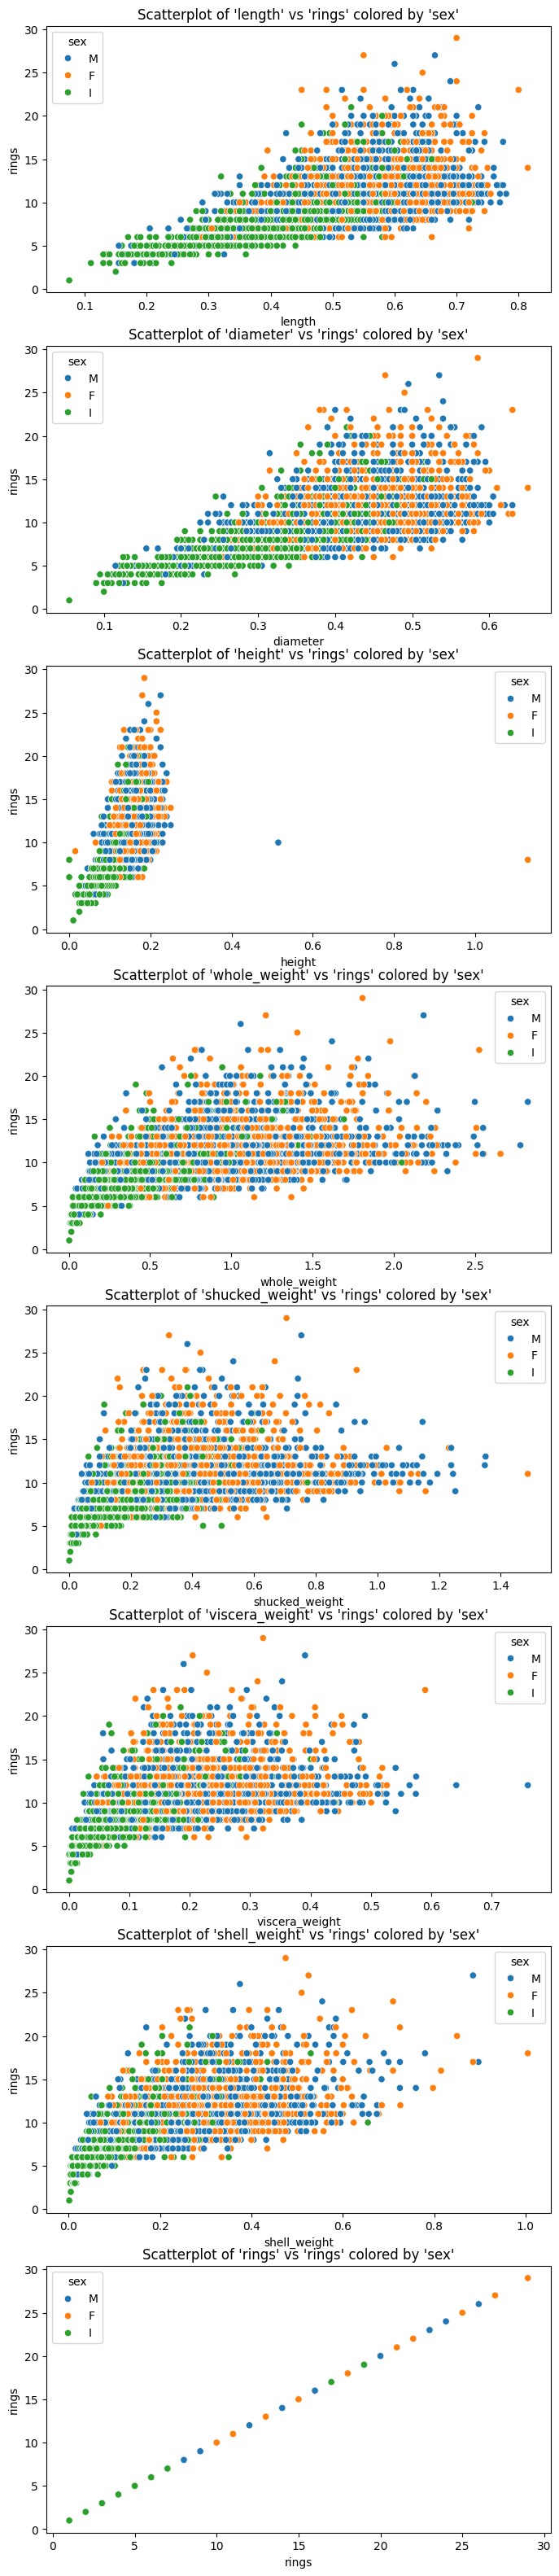

In [358]:
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(8, 5 * len(numerical_cols)))
for i, col in enumerate(numerical_cols):
    axes[i].set_title(f"Scatterplot of '{col}' vs '{target_col}' colored by 'sex'")
    sns.scatterplot(data=df, x=col, y=target_col, ax=axes[i], hue="sex")

We've seen that there are some outliers that we'd like to remove: `height`, `viscera_weight`, `shell_weight` so that we can have a generalized line. 

In [359]:
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clean_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return clean_data


In [360]:
def show_bounds(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("lower bound", lower_bound)
    print("upper bound", upper_bound)   

In [361]:
columns_remove_outliers = ["height"]

In [362]:
for col in columns_remove_outliers:
    print(f"Bounds for {col}")
    show_bounds(df, col)
    print("")

Bounds for height
lower bound 0.039999999999999994
upper bound 0.24000000000000002



In [363]:
for col in columns_remove_outliers:
    df = remove_outliers(df, col)

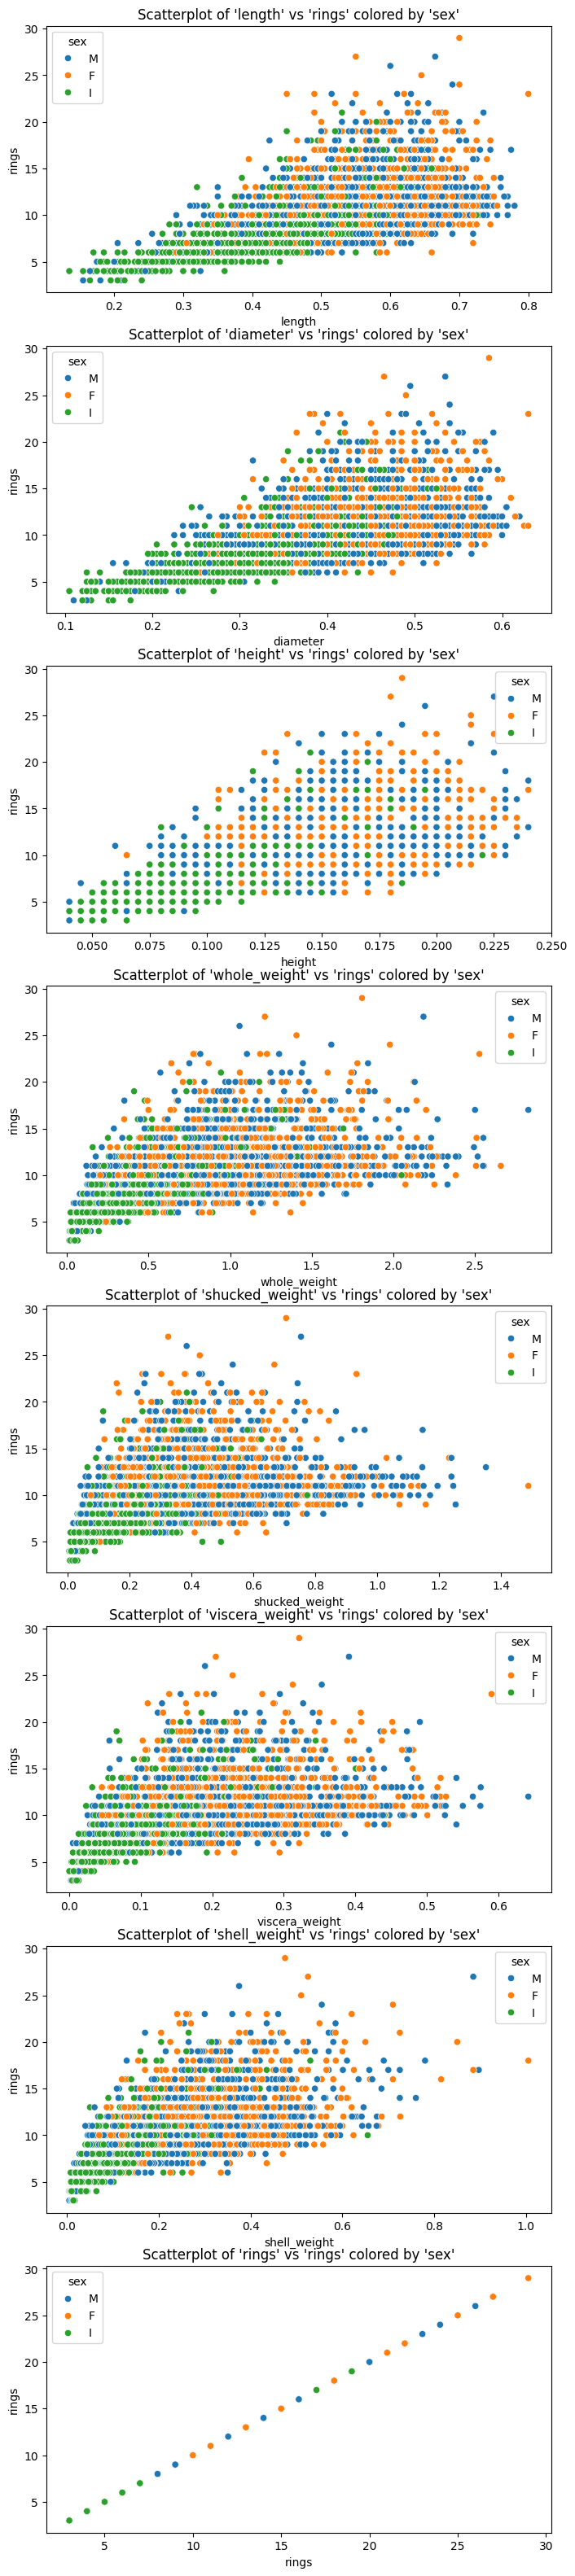

In [364]:
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(8, 5 * len(numerical_cols)))
for i, col in enumerate(numerical_cols):
    axes[i].set_title(f"Scatterplot of '{col}' vs '{target_col}' colored by 'sex'")
    sns.scatterplot(data=df, x=col, y=target_col, ax=axes[i], hue="sex")

Since we removed the outliers, we can see that the categorical column `sex` is defined as Infant (I) at low values for all the numerical columns, and that Male and Female is identified later in their growth because the higher the values, the more spread out the categorical data is.

We can see in the scatterplot that I or infant is most consistently prominent at smaller values.

Interpretation: As the abalone age, they branch out to Male or Female. At infancy, their sex cannot be identified well yet. Or maybe, there is not enough data or samples at lower values to identify at smaller values whether they are Male or Female.

## Encoding

Encode the Categorical columns (in this case `sex`) so that the model can use it

Use One Hot Encoder to avoid biases by separating them into individual columns instead of ranking them

In [365]:
from sklearn.preprocessing import OneHotEncoder

In [366]:
df.isnull().sum()

sex               0
length            0
diameter          0
height            0
whole_weight      0
shucked_weight    0
viscera_weight    0
shell_weight      0
rings             0
dtype: int64

In [367]:
ohe = OneHotEncoder(sparse_output=False)

ohe_df = pd.DataFrame(ohe.fit_transform(df[["sex"]]), columns=ohe.get_feature_names_out(["sex"]))
encoded_df = pd.concat([ohe_df, df.drop(columns=["sex"])], axis=1)
encoded_df

,sex_F,sex_I,sex_M,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,0.0,0.0,1.0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15.0
1,0.0,0.0,1.0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7.0
2,1.0,0.0,0.0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9.0
3,0.0,0.0,1.0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10.0
4,0.0,1.0,0.0,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7.0
...,...,...,...,...,...,...,...,...,...,...,...
4172,NaN,NaN,NaN,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11.0
4173,NaN,NaN,NaN,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10.0
4174,NaN,NaN,NaN,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9.0
4175,NaN,NaN,NaN,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10.0


In [368]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex_F           4148 non-null   float64
 1   sex_I           4148 non-null   float64
 2   sex_M           4148 non-null   float64
 3   length          4148 non-null   float64
 4   diameter        4148 non-null   float64
 5   height          4148 non-null   float64
 6   whole_weight    4148 non-null   float64
 7   shucked_weight  4148 non-null   float64
 8   viscera_weight  4148 non-null   float64
 9   shell_weight    4148 non-null   float64
 10  rings           4148 non-null   float64
dtypes: float64(11)
memory usage: 359.1 KB


There seems to be null values that are present by using `df.info()`. We see that the non-null count does not correspond to the whole counrs

Therefore, remove the new null datas

In [369]:
encoded_df.isna().sum()

sex_F             29
sex_I             29
sex_M             29
length            29
diameter          29
height            29
whole_weight      29
shucked_weight    29
viscera_weight    29
shell_weight      29
rings             29
dtype: int64

In [370]:
encoded_df = encoded_df.dropna()

In [371]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4119 entries, 0 to 4147
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex_F           4119 non-null   float64
 1   sex_I           4119 non-null   float64
 2   sex_M           4119 non-null   float64
 3   length          4119 non-null   float64
 4   diameter        4119 non-null   float64
 5   height          4119 non-null   float64
 6   whole_weight    4119 non-null   float64
 7   shucked_weight  4119 non-null   float64
 8   viscera_weight  4119 non-null   float64
 9   shell_weight    4119 non-null   float64
 10  rings           4119 non-null   float64
dtypes: float64(11)
memory usage: 386.2 KB


For some unexpected reason, there are row values when using OneHotEncoder that is being set to null, likely due to invisible rows presented in the data frame itself.

<Axes: >

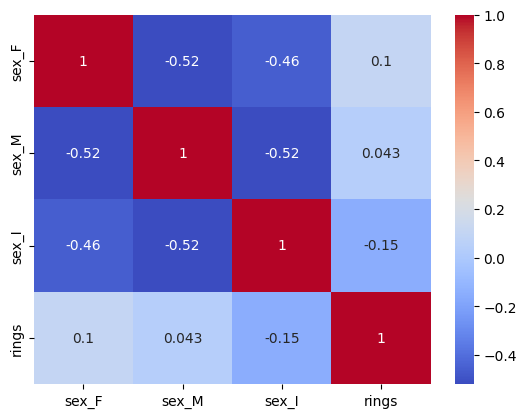

In [372]:
sex_columns = ["sex_F", "sex_M", "sex_I", "rings"]

sns.heatmap(encoded_df[sex_columns].corr(), annot=True, cmap='coolwarm')

Sex has no direct correlation with the rings, despite having a clustering at lower values. There is no linear correlation between sex and rings

## Feature Engineering

In [373]:
# Area
# length x height

encoded_df["area"] = encoded_df["length"] * encoded_df["diameter"]

# Combined Weight
# encoded_df["ave_weight"] = np.mean([encoded_df["shucked_weight"], encoded_df["shell_weight"],  encoded_df["viscera_weight"]])


In [374]:
encoded_df.head(5)

,sex_F,sex_I,sex_M,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings,area
0,0.0,0.0,1.0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15.0,0.166075
1,0.0,0.0,1.0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7.0,0.092750
2,1.0,0.0,0.0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9.0,0.222600
3,0.0,0.0,1.0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10.0,0.160600
4,0.0,1.0,0.0,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7.0,0.084150


## Split and preprocessing

In [375]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Split the columns into inputs and targets

In [376]:
X = encoded_df.drop(columns=['rings'])
y = encoded_df['rings']

In [377]:
X

,sex_F,sex_I,sex_M,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,area
0,0.0,0.0,1.0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,0.166075
1,0.0,0.0,1.0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,0.092750
2,1.0,0.0,0.0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,0.222600
3,0.0,0.0,1.0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,0.160600
4,0.0,1.0,0.0,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,0.084150
...,...,...,...,...,...,...,...,...,...,...,...
4143,1.0,0.0,0.0,0.655,0.500,0.220,1.3590,0.6420,0.3255,0.405,0.327500
4144,0.0,0.0,1.0,0.670,0.535,0.190,1.6690,0.7465,0.2935,0.508,0.358450
4145,0.0,0.0,1.0,0.670,0.525,0.200,1.7405,0.6205,0.2970,0.657,0.351750
4146,1.0,0.0,0.0,0.695,0.530,0.210,1.5100,0.6640,0.4095,0.385,0.368350


In [378]:
y

0       15.0
1        7.0
2        9.0
3       10.0
4        7.0
        ... 
4143    13.0
4144    11.0
4145    11.0
4146    10.0
4147    11.0
Name: rings, Length: 4119, dtype: float64

In [379]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scaling

Scale the data so that modals that are sensitive to distance can perform better. Ex. Linear Regression

In [380]:
scaler = StandardScaler()

In [381]:
print("Old Scale: ")
print(np.min(X_train)," <-> " ,np.max(X_train))

Old Scale: 
0.0  <->  2.8255


In [382]:
# only apply scaling to X values
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [383]:
print("New Scale:")
print(np.min(X_train_scaled)," <-> " ,np.max(X_train_scaled))

New Scale:
-3.378070698369483  <->  5.517278925841925


## Models

### Random Forest Classifier

In [384]:
from sklearn.ensemble import RandomForestClassifier

In [385]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error

In [386]:
y_test

898      4.0
2692     9.0
2731     8.0
2280     9.0
2537    11.0
        ... 
2511     6.0
958      8.0
3911    10.0
2076    10.0
3539     8.0
Name: rings, Length: 824, dtype: float64

### Hyperparameter Tuning

We want to find out which is the best parameters to use for RandomForestClassifier

In [387]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [388]:
# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Define parameter distributions for RandomizedSearchCV
param_dist = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [None] + list(np.arange(3, 15)),
    'max_features': ['sqrt', 'log2', None]
}

In [389]:
# Create and train the model
model = RandomForestClassifier(
    random_state=42
).fit(X_train_scaled, y_train)

In [396]:
# GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)
grid_search.fit(X, y)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,  # number of random samples
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X, y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, np.int64(3), ...], 'max_features': ['sqrt', 'log2', ...], 'n_estimators': array([ 50, 1...50, 200, 250])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... version

In [397]:
print("GridSearchCV Best Params:", grid_search.best_params_)
print("GridSearchCV Best Score:", grid_search.best_score_)

print("RandomizedSearchCV Best Params:", random_search.best_params_)
print("RandomizedSearchCV Best Score:", random_search.best_score_)

GridSearchCV Best Params: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 50}
GridSearchCV Best Score: 0.2680343049935708
RandomizedSearchCV Best Params: {'n_estimators': np.int64(50), 'max_features': None, 'max_depth': np.int64(5)}
RandomizedSearchCV Best Score: 0.27022054052778727


Based of the results, it seems that RandomizedSearchCV Contains the best score, so therefore we will use its params for the actual predictions.

In [392]:
rf = RandomForestClassifier(
   n_estimators=50,
   max_depth=5,
   max_features=None
).fit(X_train_scaled, y_train)

In [393]:
rf_pred = rf.predict(X_test_scaled)

In [394]:
# Compute loss to evalute the model

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("Linear Regression R2:", r2_score(y_test, rf_pred))

Linear Regression RMSE: 2.7248407809546227
Linear Regression R2: 0.3255580980677145


# Conclusion

Interpreted that our model performed poorly due to the RMSE value is very high, which means that there is a high value of loss.

These are the likely factors that contributed to this:
1. Our data set may be imbalanced. Example: There may be a significant disparity on the sampling. Meaning that there are probably more instances of Males and Females to Infants
2. We removed Outliers which could have contributed to the large amount of errors as we have limited the sampling pool even further
3. After One Hot Encoding, there was a problem with null rows. Which also contributed to the sampling being lower.
4. Feature Engineering could have more columns for the model to take in to account.

What we could have done based on the losses (Improvements):
1. Add back the outliers that may have given more impact on the models
2. Add more features in the feature engineering
3. Try to even out the samples / data or check if the data is evenly distributed
4. Use different model